# Auditing observable behaviour in qualitative biological network models
### JBCB major revision: reproducible verification and multi-interface GIM case study

This notebook executes the computational framework reported in the revised JBCB
manuscript. The primary object of inference is a **pair of explicit qualitative
models under a declared observational interface**. Formal equivalence between
those models is not interpreted as organism-level or experimental biological
equivalence.

The notebook has two logically separate parts:

1. **Formal/software verification independent of the biological case study.** Six synthetic
   model pairs have construction-level ground truth. Strong and weak results are
   cross-checked with mCRL2, and the import-to-comparison workflow is tested on
   two externally authored GINsim models: mammalian cell-cycle regulation and
   the p53--Mdm2 DNA-damage response. Three independently inferred HPN-DREAM
   model families are then fixed without test-value access and confronted with
   held-out mTOR-inhibitor phosphoproteomic responses. Weak bisimulation is also
   compared with trace equality, direct 151-graphlet/592-slot PN-GDDA, a
   transparent structural profile and labelled LTS-GDA. One-way
   simulation is independently checked by an attacker--defender game over every
   one- and two-state LTS on the declared audit alphabet. The HPN comparisons are
   also repeated under global synchronous updates.
2. **Central biological case study.** Three literature-motivated interfaces test
   where the encoded animal/human and Arabidopsis DNA-damage models retain or
   lose behavioral correspondence. Supporting curated modules remain secondary.
   Every result is conditional on the encoded models, semantics, and interface.

Additional diagnostics audit transition provenance, interface sensitivity,
silent-refinement invariance, label-permutation nulls, seed sensitivity and trace
depth. All generated tables and figures are reproducible from the public
repository: <https://github.com/cero1979/BisimulationMol>.


In [1]:
# Setup and engine import
from pathlib import Path
import sys, os

cwd = Path.cwd().resolve()
candidates = [cwd, cwd.parent]
PROJECT_ROOT = next(
    (p for p in candidates if (p / "src" / "concurrent_biomodels.py").exists()),
    None,
)
if PROJECT_ROOT is None:
    raise FileNotFoundError("Run this notebook from the project root or notebooks/ directory.")
sys.path.insert(0, str(PROJECT_ROOT / "src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pydot
from IPython.display import Image, display

import concurrent_biomodels as cbm
import method_benchmark as mb
import pn_gdda as png
import public_validation as pv
import hpn_dream_validation as hpn
import gim_interface_analysis as gim
import simulation_oracle as sim_oracle

pd.set_option("display.max_colwidth", 70)
print("Project root:", PROJECT_ROOT)
print("Available modules:", list(cbm.MODULES))


def show_petri(net, title=""):
    "Draw a Petri net with Graphviz (circle = place, box = transition)."
    g = pydot.Dot(graph_type="digraph", rankdir="LR", splines="spline",
                  nodesep="0.3", ranksep="0.6", label=title, labelloc="t",
                  fontsize="15")
    g.set_dpi("110")
    bullet = "\u25cf"
    for p in net.places:
        tok = net.init.get(p, 0)
        lbl = p if not tok else f"{p}\n{bullet*tok}"
        g.add_node(pydot.Node(f"p_{p}", shape="circle", style="filled",
                              fillcolor="#eaf1fb", color="#3b6fb5",
                              penwidth="1.6", fontsize="10", label=lbl))
    for t in net.transitions:
        tau = t.label == cbm.TAU
        sym = "\u03c4" if tau else t.label
        g.add_node(pydot.Node(f"t_{t.name}", shape="box", style="filled,rounded",
                              fillcolor="#f0f0f0" if tau else "#fff3d6",
                              color="#9a9a9a" if tau else "#c9962b",
                              penwidth="1.6", fontsize="9",
                              label=f"{t.name}\n[{sym}]"))
        for p in t.pre:
            g.add_edge(pydot.Edge(f"p_{p}", f"t_{t.name}", color="#666"))
        for p in t.post:
            g.add_edge(pydot.Edge(f"t_{t.name}", f"p_{p}", color="#666"))
    display(Image(g.create_png()))


def show_lts(lts, title=""):
    "Draw the reachability graph (LTS); τ dashed, observable solid."
    g = pydot.Dot(graph_type="digraph", rankdir="TB", label=title, labelloc="t",
                  fontsize="15")
    g.set_dpi("110")
    for i in range(len(lts.states)):
        g.add_node(pydot.Node(str(i), shape="circle", style="filled",
                              fillcolor="#d6ecd8" if i == lts.init else "#eef4fb",
                              color="#3b6fb5", fontsize="10"))
    for s, a, d in lts.edges:
        if a == cbm.TAU:
            g.add_edge(pydot.Edge(str(s), str(d), label="\u03c4", color="#9a9a9a",
                                  style="dashed", fontsize="9"))
        else:
            g.add_edge(pydot.Edge(str(s), str(d), label=a, color="#8a5a00",
                                  fontsize="9"))
    display(Image(g.create_png()))


/opt/anaconda3/lib/python3.11/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


Project root: /Users/cero/Downloads/Articulos/CompAlgMolCancer
Available modules: ['GIM', 'DCE', 'SPS', 'RCD', 'AID']


## Independent formal/software verification

The suite below is generated without using any biological case-study model.
Each pair is constructed to instantiate a known relation, so the expected result
is fixed before the algorithms are run. The binary task asks whether a pair is
strongly or weakly equivalent; one-way simulations remain visible as separate,
direction-preserving outcomes. This is not biological validation.

In [2]:
benchmark = pd.DataFrame(mb.validation_benchmark(n_steps=12, seed=17, k=8))
display(benchmark[[
    "case", "expected_class", "formal_class", "trace_distance",
    "pn_gdda_592_similarity", "pn_gdda_576_similarity",
    "lts_gda_similarity", "structural_similarity", "formal_match"
]])
assert benchmark["formal_match"].all()
print("OK: all six construction-level relations were recovered.")

,case,expected_class,formal_class,trace_distance,pn_gdda_592_similarity,pn_gdda_576_similarity,lts_gda_similarity,structural_similarity,formal_match
0,identity,strong equivalence,strong equivalence,0.0,1.000000,1.000000,1.000000,1.000000,True
1,silent refinement,weak equivalence,weak equivalence,0.0,1.000000,1.000000,0.798121,0.806250,True
2,label mismatch,not comparable,not comparable,0.8,1.000000,1.000000,0.718750,0.900000,True
3,label order swap,not comparable,not comparable,0.5,1.000000,1.000000,0.884615,1.000000,True
4,added branch,reference simulated by candidate,reference simulated by candidate,0.1,0.967638,0.966739,0.914359,0.893681,True
5,trace-equivalent branching,candidate simulated by reference,candidate simulated by reference,0.0,0.965731,0.964779,0.527845,0.775000,True


OK: all six construction-level relations were recovered.


### Comparison with non-formal baselines

PN-GDDA is evaluated directly using all 151 connected directed bipartite
graphlets through five nodes and the 592 orbit slots implemented by Holmes. Each
synthetic LTS is encoded canonically as a state-machine Petri net. LTS-GDA is a
separate label-aware reachable-state baseline combining four graphlet orbits
with directed labelled motifs. The simpler structural profile averages state
count, edge count, label multiset and out-degree multiset. The trace baseline
compares observable languages through depth eight. These methods test
complementary local, linear-time and branching-time views.

In [3]:
baseline = pd.DataFrame(mb.baseline_accuracy(benchmark.to_dict("records")))
pn_thresholds = pd.DataFrame(
    mb.pn_gdda_threshold_sensitivity(benchmark.to_dict("records"))
)
display(baseline)
display(pn_thresholds)
assert float(baseline.loc[baseline["method"] == "weak bisimulation", "accuracy"].iloc[0]) == 1.0
assert benchmark.loc[
    benchmark["case"] == "trace-equivalent branching", "trace_equivalent_at_k"
].iloc[0]
assert benchmark.loc[
    benchmark["case"] == "label order swap", "structurally_equivalent_at_0_9"
].iloc[0]
assert float(baseline.loc[baseline["method"] == "LTS-GDA (>=0.9)", "accuracy"].iloc[0]) == 4 / 6
assert float(baseline.loc[baseline["method"] == "PN-GDDA-592 (>=0.9)", "accuracy"].iloc[0]) == 2 / 6
assert float(pn_thresholds["accuracy"].max()) == 4 / 6
print("OK: the benchmark exposes the predeclared trace-only and structure-only failure cases.")

,method,accuracy,true_positive,true_negative,false_positive,false_negative,n_cases
0,weak bisimulation,1.000000,2,4,0,0,6
1,trace equality (k=8),0.833333,2,3,1,0,6
2,PN-GDDA-592 (>=0.9),0.333333,2,0,4,0,6
3,LTS-GDA (>=0.9),0.666667,1,3,1,1,6
4,structural profile (>=0.9),0.500000,1,2,2,1,6


,threshold,is_predeclared_0_9,accuracy,true_positive,true_negative,false_positive,false_negative
0,0.000000,False,0.333333,2,0,4,0
1,0.900000,True,0.333333,2,0,4,0
2,0.965731,False,0.333333,2,0,4,0
3,0.965731,False,0.500000,2,1,3,0
4,0.967638,False,0.500000,2,1,3,0
5,0.967638,False,0.666667,2,2,2,0
6,1.000000,False,0.666667,2,2,2,0


OK: the benchmark exposes the predeclared trace-only and structure-only failure cases.


### Direct PN-GDDA catalog and native-net audit

The published/Holmes 592-slot catalog is the primary comparator. A separate
type- and direction-preserving automorphism reconstruction yields 576 distinct
orbits and is retained as a sensitivity analysis. The four-node reference pair
below was also run independently in Holmes 1.1.1; `make holmes-pn-gdda` verifies
all 151 topology signatures and 592 root assignments from the official JAR.
The machine-readable record contains the JAR hash and both numerical scores. The five curated pairs are
then compared in their original Petri-net form rather than through reachable
LTS summaries.

In [4]:
import json

pn_catalog = png.catalog_validation()
pn_native = pd.DataFrame(png.native_module_comparisons(k=6))
with open(PROJECT_ROOT / "results" / "holmes_pn_gdda_external_validation.json") as handle:
    holmes_external = json.load(handle)
display(pd.DataFrame(pn_catalog["published_holmes_catalog"]))
display(pd.DataFrame(pn_catalog["automorphism_partition_sensitivity"]))
display(pn_native[[
    "module", "pn_gdda_592_similarity", "pn_gdda_576_similarity",
    "pn_gdda_equivalent_at_0_9", "formal_class"
]])
print("Holmes reference:", pn_catalog["holmes_reference_score"])
print("Independent score:", pn_catalog["independent_python_score"])
print("External catalog audit:", holmes_external)

assert pn_catalog["published_graphlet_total"] == 151
assert pn_catalog["published_orbit_slot_total"] == 592
assert pn_catalog["automorphism_orbit_total"] == 576
assert pn_catalog["score_agreement_at_12_decimals"]
assert holmes_external["catalog_matches_python"]
assert holmes_external["holmes_graphlet_topologies"] == 151
assert holmes_external["holmes_catalog_slots_verified"] == 592
assert pn_native["pn_gdda_equivalent_at_0_9"].all()
assert (pn_native["catalog_sensitivity_delta"].abs() < 0.001).all()
print("OK: direct PN-GDDA is reproduced, externally checked and sensitivity-audited.")

,size,graphlets,orbits
0,2,2,4
1,3,6,14
2,4,23,72
3,5,120,502


,size,graphlets,orbits
0,2,2,4
1,3,6,14
2,4,23,72
3,5,120,486


,module,pn_gdda_592_similarity,pn_gdda_576_similarity,pn_gdda_equivalent_at_0_9,formal_class
0,GIM,0.997585,0.997517,True,weak equivalence
1,DCE,0.996882,0.996795,True,weak equivalence
2,SPS,1.000000,1.000000,True,weak equivalence
3,RCD,1.000000,1.000000,True,one-way simulation
4,AID,0.990685,0.990427,True,not comparable


Holmes reference: 0.987202746587073
Independent score: 0.9872027465870733
External catalog audit: {'absolute_score_difference': 3.3306690738754696e-16, 'agreement_at_12_decimals': True, 'catalog_matches_python': True, 'download_url': 'https://www.cs.put.poznan.pl/mradom/Holmes/HolmesRelease_111.zip', 'holmes_catalog_slots_verified': 592, 'holmes_graphlet_topologies': 151, 'holmes_orbit_slots': 592, 'holmes_score': 0.987202746587073, 'holmes_version': '1.1.1', 'independent_python_score': 0.9872027465870733, 'jar_sha256': '1747a9798c074a4e8a560cded9396ec3d0be05af2d948953c7730d5e623f044c'}
OK: direct PN-GDDA is reproduced, externally checked and sensitivity-audited.


### Independent mCRL2 oracle and public models

Every LTS is exported in Aldebaran AUT format and checked by `ltscompare` from
mCRL2 202607.0. The comparison covers strong bisimulation, weak bisimulation
and exact weak-trace equivalence. One-way simulation is checked separately by a
dual attacker--defender least-fixed-point game on all 67,600 ordered pairs of
the 260 LTSs having at most two states over `{a, tau}`. The same import path is
then exercised on two public
GINsim models with source URLs and SHA-256 hashes fixed in the repository.

For each external model, an exact copy is a positive strong control, a silent
refinement is a weak-only positive control, and an observable-label perturbation
is a negative control. These transformations test importer and checker behaviour
on externally authored dynamics; they do not validate the model's biology.

In [5]:
public_models = pd.DataFrame(pv.public_model_summary())
display(public_models[[
    "model", "format", "variables", "theoretical_state_space",
    "reachable_states", "reachable_edges", "initial_condition", "sha256"
]])

mcrl2_synthetic = pd.DataFrame(pv.run_synthetic_mcrl2_validation())
public_controls = pd.DataFrame(pv.run_public_validation())
public_semantics = pd.DataFrame(pv.public_semantic_sensitivity())
simulation_audit = sim_oracle.exhaustive_simulation_validation(max_states=2)
display(mcrl2_synthetic[[
    "case", "python_mcrl2_strong_agree", "python_mcrl2_weak_agree",
    "mcrl2_trace_matches_predeclared", "mcrl2_version"
]])
display(public_controls[[
    "model", "case", "expected_strong", "expected_weak",
    "python_strong_bisimilar", "python_weak_bisimilar",
    "mcrl2_strong_bisimilar", "mcrl2_weak_bisimilar",
    "mcrl2_weak_trace_equivalent", "all_expected_results_match"
]])
display(public_semantics)
display(pd.DataFrame([{k: v for k, v in simulation_audit.items() if k != "counterexamples"}]))

assert mcrl2_synthetic["python_mcrl2_strong_agree"].all()
assert mcrl2_synthetic["python_mcrl2_weak_agree"].all()
assert mcrl2_synthetic["mcrl2_trace_matches_predeclared"].all()
assert public_controls["all_expected_results_match"].all()
assert simulation_audit["complete_agreement"]
print("OK: mCRL2 and the exhaustive simulation-game oracle agree with every declared audit.")

,model,format,variables,theoretical_state_space,reachable_states,reachable_edges,initial_condition,sha256
0,mammalian_cell_cycle,SBML-qual,13,8192,826,3413,CycD=1; all other components=0,105eb2d1b44532762632245537315396c4deb912f1e1754b70edf2bdf2d9f02e
1,p53_mdm2,GINML,4,36,17,26,GINsim stored state 'damage',511a7b0f7764ca88efbbe38fb6fe28d89a7080d34bc2fc5277b3c750026b6d81


,case,python_mcrl2_strong_agree,python_mcrl2_weak_agree,mcrl2_trace_matches_predeclared,mcrl2_version
0,identity,True,True,True,ltscompare mCRL2 toolset 202607.0 (Release)
1,silent refinement,True,True,True,ltscompare mCRL2 toolset 202607.0 (Release)
2,label mismatch,True,True,True,ltscompare mCRL2 toolset 202607.0 (Release)
3,label order swap,True,True,True,ltscompare mCRL2 toolset 202607.0 (Release)
4,added branch,True,True,True,ltscompare mCRL2 toolset 202607.0 (Release)
5,trace-equivalent branching,True,True,True,ltscompare mCRL2 toolset 202607.0 (Release)


,model,case,expected_strong,expected_weak,python_strong_bisimilar,python_weak_bisimilar,mcrl2_strong_bisimilar,mcrl2_weak_bisimilar,mcrl2_weak_trace_equivalent,all_expected_results_match
0,mammalian_cell_cycle,exact copy,True,True,True,True,True,True,True,True
1,mammalian_cell_cycle,silent refinement,False,True,False,True,False,True,True,True
2,mammalian_cell_cycle,observable perturbation,False,False,False,False,False,False,False,True
3,p53_mdm2,exact copy,True,True,True,True,True,True,True,True
4,p53_mdm2,silent refinement,False,True,False,True,False,True,True,True
5,p53_mdm2,observable perturbation,False,False,False,False,False,False,False,True


,model,asynchronous_states,asynchronous_edges,synchronous_states,synchronous_edges,common_reachable_states,reachable_state_jaccard,asynchronous_terminal_states,synchronous_terminal_states
0,mammalian_cell_cycle,826,3413,13,13,13,0.015738,0,0
1,p53_mdm2,17,26,8,7,8,0.470588,1,1


,max_states,alphabet,number_of_lts,ordered_lts_pairs,agreements,disagreements,complete_agreement,oracle
0,2,a;tau,260,67600,67600,0,True,dual attacker-defender least-fixed-point game


OK: mCRL2 and the exhaustive simulation-game oracle agree with every declared audit.


### GIM as a biological observational-interface experiment

The animal/human and Arabidopsis Petri-net structures are held fixed. Three
literature-motivated interfaces are declared before interpreting the formal
outcomes: A observes shared functions, B separates damage, signalling and
repair channels, and C additionally distinguishes apoptosis from the encoded
plant SMR and terminal response. Thus any change below is caused by
observational resolution rather than topology.

In [6]:
gim_output_paths = gim.write_outputs()
gim_interfaces = pd.DataFrame(gim.analysis_rows(k=6))
display(gim_interfaces[[
    "interface_id", "interface_name", "observable_labels",
    "animal_model_states", "plant_model_states",
    "animal_simulated_by_plant", "plant_simulated_by_animal",
    "formal_class", "trace_distance_k6", "pn_gdda_592_similarity"
]])

assert list(gim_interfaces["formal_class"]) == [
    "weak_bisimulation", "weak_bisimulation", "not_comparable"
]
assert np.allclose(gim_interfaces["trace_distance_k6"], [0.0, 0.0, 6 / 17])
assert gim_interfaces["pn_gdda_592_similarity"].nunique() == 1
assert not gim_interfaces["structure_changed_between_interfaces"].any()
assert all(path.exists() for path in gim_output_paths)
print("OK: unchanged structure, interface-dependent GIM behavioural result.")

,interface_id,interface_name,observable_labels,animal_model_states,plant_model_states,animal_simulated_by_plant,plant_simulated_by_animal,formal_class,trace_distance_k6,pn_gdda_592_similarity
0,A,coarse functional/process,cell_cycle_exit;checkpoint_activation;damage_detection;repair;rest...,13,14,True,True,weak_bisimulation,0.000000,0.997585
1,B,intermediate pathway,atm_pathway_signal;atr_pathway_signal;cell_cycle_exit;checkpoint_a...,13,14,True,True,weak_bisimulation,0.000000,0.997585
2,C,mechanism-resolved terminal fate,apoptosis;atm_pathway_signal;atr_pathway_signal;checkpoint_activat...,13,14,False,False,not_comparable,0.352941,0.997585


OK: unchanged structure, interface-dependent GIM behavioural result.


### Exploratory HPN-DREAM check against held-out data

The public BT20, BT549 and MCF7 families were inferred from learning data by
Razzaq et al. A representative is selected solely from within-family clause
similarity; an anti-leakage test prevents this step from opening the held-out
files. The exact intersection of three mTOR-inhibitor conditions and seven
PI3K/MAPK/mTOR readouts defines the comparison before response values are used.

This is not another transformed control. The source models, cell contexts and
experimental profiles are genuinely distinct. The analysis remains exploratory.
Formal relations are nominal and one-way simulation is directional, so no
ordinal class score or class/RMSE inferential test is computed.

In [7]:
import json

hpn_medoids = pd.DataFrame(hpn.medoid_summary())
hpn_formal = pd.DataFrame(hpn.validation_rows(use_mcrl2=True))
hpn_stats = hpn.concordance_test(hpn_formal.to_dict("records"))
hpn_semantics = pd.DataFrame(hpn.semantic_sensitivity_rows())
hpn_caspots = pd.read_csv(PROJECT_ROOT / "results" / "hpn_dream_caspots_rmse.csv")
with open(PROJECT_ROOT / "results" / "hpn_dream_caspots_summary.json") as handle:
    hpn_caspots_summary = json.load(handle)

display(hpn_medoids[[
    "cell_line", "family_size", "medoid_row_zero_based", "active_clauses",
    "mean_within_family_jaccard", "selection_uses_heldout_data"
]])
display(hpn_formal[[
    "condition", "left_cell", "right_cell", "left_states", "right_states",
    "formal_class", "relation_direction", "experimental_rmse", "trace_distance_k6",
    "lts_gda_similarity",
    "python_mcrl2_strong_agree", "python_mcrl2_weak_agree"
]])
display(hpn_semantics)
display(hpn_caspots[hpn_caspots["selection"] == "blind_structure_medoid"][[
    "source_cell", "target_cell", "native_context", "discrete_rmse",
    "model_rmse", "excess_rmse", "deterministic_across_repeats"
]])
print("Nominal relation/data summary and continuous diagnostics:", hpn_stats)
print("Native specificity:", hpn_caspots_summary)

assert not hpn_medoids["selection_uses_heldout_data"].any()
assert hpn_formal["python_mcrl2_strong_agree"].all()
assert hpn_formal["python_mcrl2_weak_agree"].all()
assert not hpn_formal["weak_bisimilar"].any()
assert not hpn_stats["formal_class_scalar_encoding_used"]
assert not hpn_stats["formal_class_inferential_test_performed"]
assert "formal_class_spearman_rho" not in hpn_stats
assert int(hpn_semantics["class_preserved"].sum()) == 7
assert hpn_caspots["deterministic_across_repeats"].all()
print("OK: independent models and held-out data were evaluated without test leakage.")

,cell_line,family_size,medoid_row_zero_based,active_clauses,mean_within_family_jaccard,selection_uses_heldout_data
0,BT20,72,24,29,0.814883,False
1,BT549,191,137,25,0.853880,False
2,MCF7,21,9,23,0.850549,False


,condition,left_cell,right_cell,left_states,right_states,formal_class,relation_direction,experimental_rmse,trace_distance_k6,lts_gda_similarity,python_mcrl2_strong_agree,python_mcrl2_weak_agree
0,mTORi,BT20,BT549,8,2,one_way_simulation,right_simulated_by_left,0.191884,0.888889,0.212112,True,True
1,mTORi,BT20,MCF7,8,16,not_comparable,no_simulation_relation,0.306253,0.800000,0.179054,True,True
2,mTORi,BT549,MCF7,2,16,one_way_simulation,left_simulated_by_right,0.255898,0.888889,0.202130,True,True
3,IGF1+mTORi,BT20,BT549,24,6,one_way_simulation,right_simulated_by_left,0.185483,0.942857,0.237828,True,True
4,IGF1+mTORi,BT20,MCF7,24,44,not_comparable,no_simulation_relation,0.200407,0.907407,0.408908,True,True
5,IGF1+mTORi,BT549,MCF7,6,44,not_comparable,no_simulation_relation,0.207070,0.960000,0.251852,True,True
6,4EBP1+mTORi,BT20,BT549,4,2,one_way_simulation,right_simulated_by_left,0.227730,0.666667,0.260723,True,True
7,4EBP1+mTORi,BT20,MCF7,4,16,one_way_simulation,left_simulated_by_right,0.275652,0.666667,0.156250,True,True
8,4EBP1+mTORi,BT549,MCF7,2,16,one_way_simulation,left_simulated_by_right,0.277565,0.888889,0.202130,True,True


,condition,left_cell,right_cell,asynchronous_class,synchronous_class,class_preserved,asynchronous_trace_distance_k6,synchronous_trace_distance_k6,asynchronous_lts_gda_similarity,synchronous_lts_gda_similarity,asynchronous_left_states,asynchronous_right_states,synchronous_left_states,synchronous_right_states
0,mTORi,BT20,BT549,one_way_simulation,one_way_simulation,True,0.888889,0.666667,0.212112,0.298223,8,2,3,2
1,mTORi,BT20,MCF7,not_comparable,not_comparable,True,0.800000,0.800000,0.179054,0.600000,8,16,3,3
2,mTORi,BT549,MCF7,one_way_simulation,one_way_simulation,True,0.888889,0.666667,0.202130,0.298223,2,16,2,3
3,IGF1+mTORi,BT20,BT549,one_way_simulation,not_comparable,False,0.942857,0.750000,0.237828,0.500000,24,6,3,3
4,IGF1+mTORi,BT20,MCF7,not_comparable,not_comparable,True,0.907407,0.833333,0.408908,0.554762,24,44,3,4
5,IGF1+mTORi,BT549,MCF7,not_comparable,not_comparable,True,0.960000,0.800000,0.251852,0.483333,6,44,3,4
6,4EBP1+mTORi,BT20,BT549,one_way_simulation,one_way_simulation,True,0.666667,0.666667,0.260723,0.298223,4,2,3,2
7,4EBP1+mTORi,BT20,MCF7,one_way_simulation,not_comparable,False,0.666667,0.800000,0.156250,0.600000,4,16,3,3
8,4EBP1+mTORi,BT549,MCF7,one_way_simulation,one_way_simulation,True,0.888889,0.666667,0.202130,0.298223,2,16,2,3


,source_cell,target_cell,native_context,discrete_rmse,model_rmse,excess_rmse,deterministic_across_repeats
0,BT20,BT20,True,0.329438,0.330238,0.000800,True
1,BT20,BT549,False,0.300787,0.311269,0.010482,True
2,BT20,MCF7,False,0.277255,0.277255,0.000000,True
3,BT549,BT20,False,0.329438,0.336711,0.007273,True
4,BT549,BT549,True,0.300787,0.313348,0.012561,True
5,BT549,MCF7,False,0.277255,0.283732,0.006476,True
6,MCF7,BT20,False,0.329438,0.334118,0.004680,True
7,MCF7,BT549,False,0.300787,0.311310,0.010524,True
8,MCF7,MCF7,True,0.277255,0.277255,0.000000,True


Nominal relation/data summary and continuous diagnostics: {'n_model_pair_conditions': 9, 'n_conditions': 3, 'formal_relation_analysis': 'nominal and direction-preserving descriptive summary', 'formal_class_scalar_encoding_used': False, 'formal_class_inferential_test_performed': False, 'reason_no_formal_class_inference': 'n=9 is too small and directional simulation classes do not define a biologically justified one-dimensional order', 'formal_class_rmse_summary': {'one_way_simulation': {'n': 6, 'rmse_min': 0.18548338629376107, 'rmse_median': 0.24181422976946154, 'rmse_max': 0.2775650222375332}, 'not_comparable': {'n': 3, 'rmse_min': 0.2004067518442206, 'rmse_median': 0.20707024211425681, 'rmse_max': 0.30625328009383596}}, 'relation_direction_rmse_summary': {'left_simulated_by_right': {'n': 3, 'rmse_min': 0.25589837040251756, 'rmse_median': 0.27565206422635075, 'rmse_max': 0.2775650222375332}, 'right_simulated_by_left': {'n': 3, 'rmse_min': 0.18548338629376107, 'rmse_median': 0.191884390

### Runtime scaling

Median wall-clock times are measured over three repetitions. They are expected
to vary by machine and load; the state counts, edge counts, candidate relation
sizes and formal outcomes are deterministic.

,n_steps,variant,n_states_reference,n_states_candidate,candidate_relation_pairs,total_runtime_ms,formal_class
0,8,identity,9,9,81,0.374917,strong equivalence
1,8,silent refinement,9,10,90,0.427583,weak equivalence
2,16,identity,17,17,289,1.902876,strong equivalence
3,16,silent refinement,17,19,323,1.946792,weak equivalence
4,32,identity,33,33,1089,10.820375,strong equivalence
5,32,silent refinement,33,37,1221,11.306833,weak equivalence
6,64,identity,65,65,4225,72.459417,strong equivalence
7,64,silent refinement,65,73,4745,73.531500,weak equivalence
8,96,identity,97,97,9409,252.902250,strong equivalence
9,96,silent refinement,97,109,10573,250.118917,weak equivalence


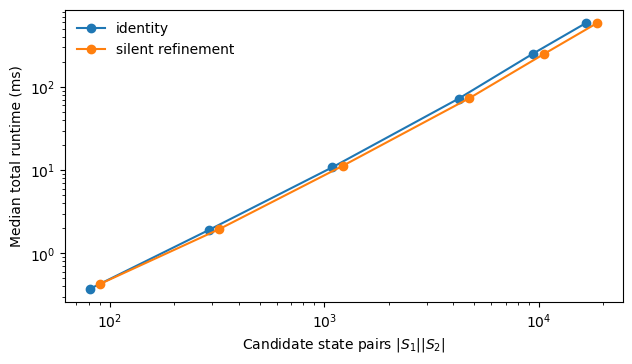

In [8]:
scaling = pd.DataFrame(mb.scalability_benchmark(
    sizes=(8, 16, 32, 64, 96, 128), repeats=3, seed=23
))
display(scaling[[
    "n_steps", "variant", "n_states_reference", "n_states_candidate",
    "candidate_relation_pairs", "total_runtime_ms", "formal_class"
]])

fig, ax = plt.subplots(figsize=(7.2, 3.8))
for variant, group in scaling.groupby("variant", sort=False):
    ax.plot(group["candidate_relation_pairs"], group["total_runtime_ms"],
            marker="o", label=variant)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel(r"Candidate state pairs $|S_1||S_2|$")
ax.set_ylabel("Median total runtime (ms)")
ax.legend(frameon=False)
plt.show()

## Phase 1 — Biological delimitation of comparable modules

Gene counts per hallmark (Table 1 of Clavijo‑Buriticá et al. 2023): *H. sapiens*
(associated genes) and *A. thaliana* (unique orthologs). We keep the four
prioritised modules in which concurrency is intrinsic (parallel routes, conflict,
checkpoints).

,Hallmark,H. sapiens,A. thaliana (orth.),Prioritised
SPS,Sustaining Proliferative Signaling,1927,454,★
AIM,Activating Invasion & Metastasis,1834,252,
DCE,Deregulating Cellular Energetics,1086,386,★
RCD,Resisting Cell Death,1072,211,★
AID,Avoiding Immune Destruction,1063,166,
TPI,Tumor Promoting Inflammation,536,39,
GIM,Genome Instability & Mutation,466,167,★
IA,Inducing Angiogenesis,337,25,
EGS,Evading Growth Suppressors,246,34,
ERI,Enabling Replicative Immortality,161,59,★


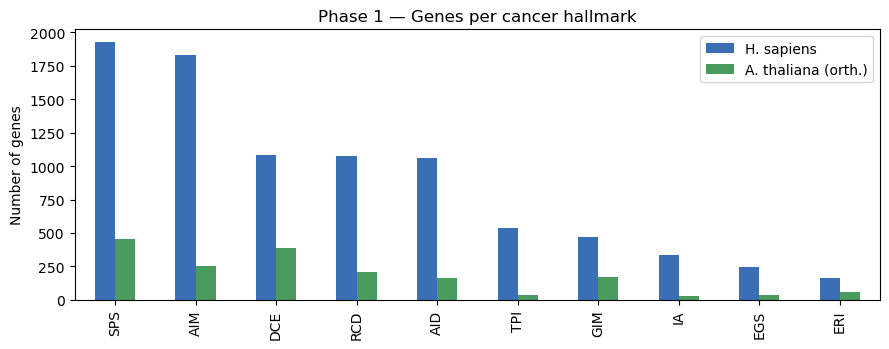

In [9]:
d = cbm.HALLMARK_GENE_COUNTS
df1 = (pd.DataFrame(d).T
       .rename(columns={"name": "Hallmark", "human": "H. sapiens",
                        "ath": "A. thaliana (orth.)", "prio": "Prioritised"})
       .sort_values("H. sapiens", ascending=False))
df1["Prioritised"] = df1["Prioritised"].map({1: "\u2605", 0: ""})
display(df1)

ax = df1[["H. sapiens", "A. thaliana (orth.)"]].plot(
    kind="bar", figsize=(9, 3.6), color=["#3b6fb5", "#4a9b5e"])
ax.set_ylabel("Number of genes"); ax.set_title("Phase 1 — Genes per cancer hallmark")
plt.tight_layout(); plt.show()

## Phase 2 — Conserved active subnetworks

For each module we curate a subnetwork of components with their plant ortholog and
a conservation flag from the primary references. The **conservation index** is the
fraction of components with a conserved functional ortholog.

,module,total_components,conserved_components,conservation_index,user_module
0,GIM,10,8,0.80,DNA repair and genome instability
1,DCE,7,7,1.00,Central energy metabolism
2,SPS,7,7,1.00,Cell-cycle regulation
3,RCD,8,6,0.75,Programmed cell death and autophagy
4,AID,5,3,0.60,Immune evasion (not prioritised)


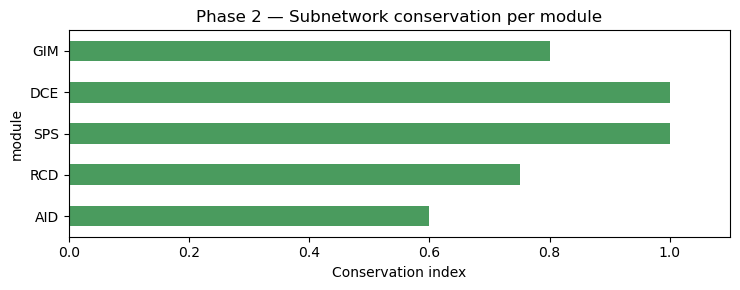

In [10]:
cons = pd.DataFrame([cbm.conservation_index(m) for m in cbm.MODULES])
cons["user_module"] = [cbm.MODULES[m]["user_module"] for m in cons["module"]]
display(cons)

ax = cons.plot(x="module", y="conservation_index", kind="barh", legend=False,
               figsize=(7.5, 3), color="#4a9b5e")
ax.set_xlabel("Conservation index"); ax.set_xlim(0, 1.1)
ax.set_title("Phase 2 — Subnetwork conservation per module")
ax.invert_yaxis(); plt.tight_layout(); plt.show()

In [11]:
# Curated GIM subnetwork and the transition-level provenance that makes the
# Petri net auditable (this is what turns 'hand-built' into 'reproducible').
gim = pd.DataFrame(cbm.CONSERVED_SUBNETWORKS["GIM"],
                   columns=["Human/animal", "A. thaliana ortholog", "Role", "Conserved"])
display(gim)

prov = pd.DataFrame(cbm.MODEL_PROVENANCE["GIM"],
                    columns=["Transition(s)", "Biological event", "Evidence"])
display(prov)

prov_all = pd.DataFrame(
    [(m, tr, ev, ref) for m in cbm.MODULES for tr, ev, ref in cbm.MODEL_PROVENANCE[m]],
    columns=["Module", "Transition(s)", "Biological event", "Evidence"],
)
display(prov_all)

coverage = pd.DataFrame([cbm.provenance_coverage(m) for m in cbm.MODULES])
display(coverage[["module", "n_transitions", "n_provenance_rows", "n_uncovered", "uncovered", "complete"]])
assert coverage["complete"].all(), coverage[["module", "uncovered"]].to_string(index=False)
print("OK: every Petri-net transition is named in the module provenance table.")


,Human/animal,A. thaliana ortholog,Role,Conserved
0,ATM,ATM (AT3G48190),DSB sensor,True
1,ATR,ATR (AT5G40820),SSB sensor,True
2,CHK1,WEE1 (AT1G02970),Transducer/arrest,True
3,CHK2,WEE1 (AT1G02970),Transducer/arrest,True
4,CDKN1A/p21,SMR (SMR1-13),CDK inhibitor,True
5,MCM2-7,MCM2-7 (AtMCM),Replicative helicase,True
6,ORC1-6,ORC1-6 (AtORC),Origin complex,True
7,BRCA1,BRCA1 (AT4G21070),HR repair,True
8,TP53/p53,-,Apoptotic hub (not conserved),False
9,CDC25,-,G2-M phosphatase (absent in plant),False


,Transition(s),Biological event,Evidence
0,sense_DSB,ATM-associated double-strand-break signalling,"JacksonBartek2009, BlackfordJackson2017, Yoshiyama2013"
1,sense_SSB,ATR-associated ssDNA/replication-stress signalling,"BlackfordJackson2017, Yoshiyama2013"
2,ATM_CHK2 / ATR_CHK1 / ATM_sig / ATR_sig / SOG1_program,animal checkpoint relays and the plant-specific SOG1 programme,"BlackfordJackson2017, Adachi2011, Ogita2018"
3,CHK_p53 / p53_p21_arrest / WEE1_arrest,cell-cycle arrest (p53-p21-CDK / SOG1-WEE1),"JacksonBartek2009, DeSchutter2007, Ogita2018"
4,repair_HR_NHEJ / repair_BER_NER,broad DSB and excision-repair families,"JacksonBartek2009, ManovaGruszka2015"
5,repair_ok / repair_fail,encoded recovery or unresolved-damage branch,"JacksonBartek2009, Yoshiyama2013"
6,apoptosis (animal),encoded apoptotic loss from the proliferative pool,JacksonBartek2009
7,SMR_induction + differentiation (plant),SMR-associated arrest and a combined differentiation/endoreduplica...,"Yi2014, Adachi2011, FulcherSablowski2009"


,Module,Transition(s),Biological event,Evidence
0,GIM,sense_DSB,ATM-associated double-strand-break signalling,"JacksonBartek2009, BlackfordJackson2017, Yoshiyama2013"
1,GIM,sense_SSB,ATR-associated ssDNA/replication-stress signalling,"BlackfordJackson2017, Yoshiyama2013"
2,GIM,ATM_CHK2 / ATR_CHK1 / ATM_sig / ATR_sig / SOG1_program,animal checkpoint relays and the plant-specific SOG1 programme,"BlackfordJackson2017, Adachi2011, Ogita2018"
3,GIM,CHK_p53 / p53_p21_arrest / WEE1_arrest,cell-cycle arrest (p53-p21-CDK / SOG1-WEE1),"JacksonBartek2009, DeSchutter2007, Ogita2018"
4,GIM,repair_HR_NHEJ / repair_BER_NER,broad DSB and excision-repair families,"JacksonBartek2009, ManovaGruszka2015"
5,GIM,repair_ok / repair_fail,encoded recovery or unresolved-damage branch,"JacksonBartek2009, Yoshiyama2013"
6,GIM,apoptosis (animal),encoded apoptotic loss from the proliferative pool,JacksonBartek2009
7,GIM,SMR_induction + differentiation (plant),SMR-associated arrest and a combined differentiation/endoreduplica...,"Yi2014, Adachi2011, FulcherSablowski2009"
8,DCE,glucose_uptake / glycolysis,conserved glycolysis,CB2023
9,DCE,respiration / oxphos,TCA cycle and oxidative phosphorylation,CB2023


,module,n_transitions,n_provenance_rows,n_uncovered,uncovered,complete
0,GIM,17,8,0,[],True
1,DCE,7,4,0,[],True
2,SPS,7,4,0,[],True
3,RCD,7,5,0,[],True
4,AID,6,3,0,[],True


OK: every Petri-net transition is named in the module provenance table.


## Phase 3 — Common observational interface

The interface is the set of **observables** shared by both species; everything
else is an internal event `τ`. An event is admitted as observable only if it maps
to an experimentally meaningful read-out in both organisms. This shifts the
comparison from molecular identity to observable functional comparability.

In [12]:
rows = []
for m, spec in cbm.MODULES.items():
    obs_a = spec["animal"]().reachability_lts().observables
    obs_p = spec["plant"]().reachability_lts().observables
    rows.append({"module": m,
                 "common interface (\u2229)": sorted(obs_a & obs_p),
                 "animal only": sorted(obs_a - obs_p),
                 "plant only": sorted(obs_p - obs_a)})
pd.DataFrame(rows)

,module,common interface (∩),animal only,plant only
0,GIM,"[checkpoint, damage, exit_cycle, repair, restored]",[],[]
1,DCE,"[atp, branch_resp, glycolysis, reprogram, uptake]",[],[]
2,SPS,"[division, g1s, g2m, licensing, mitogen, sphase]",[],[]
3,RCD,"[autophagy, mtor_off, pcd_commit, stress, survive]",[apoptosis],[]
4,AID,"[effector, innate_signal, recognition]","[clonal_selection, memory]",[cell_wall]


## Phase 4 — Concurrent formalisation (Petri nets)

Places = molecular states/resources; transitions = regulatory events (observable
or `τ`); tokens = activation. Worked example: **GIM** (DNA damage response). The
plant replaces *apoptosis* by *differentiation* preceded by the internal
induction of **SMR** (`τ`). We also verify the nets are **safe** (1‑bounded).

GIM animal: 12 places, 11 transitions, safe = True
GIM plant : 13 places, 12 transitions, safe = True


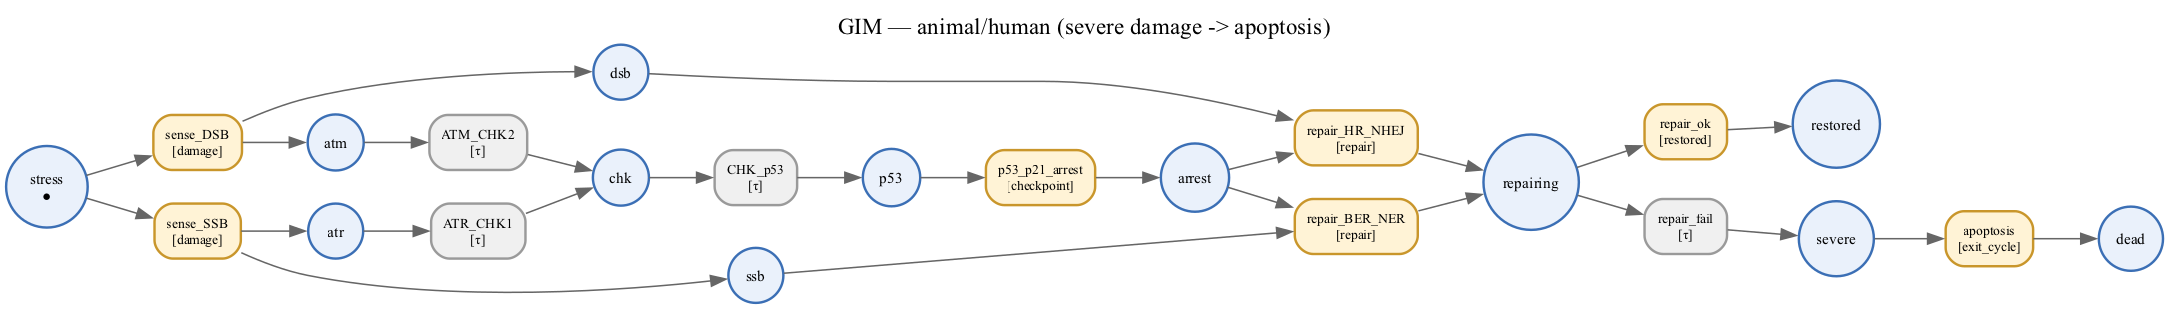

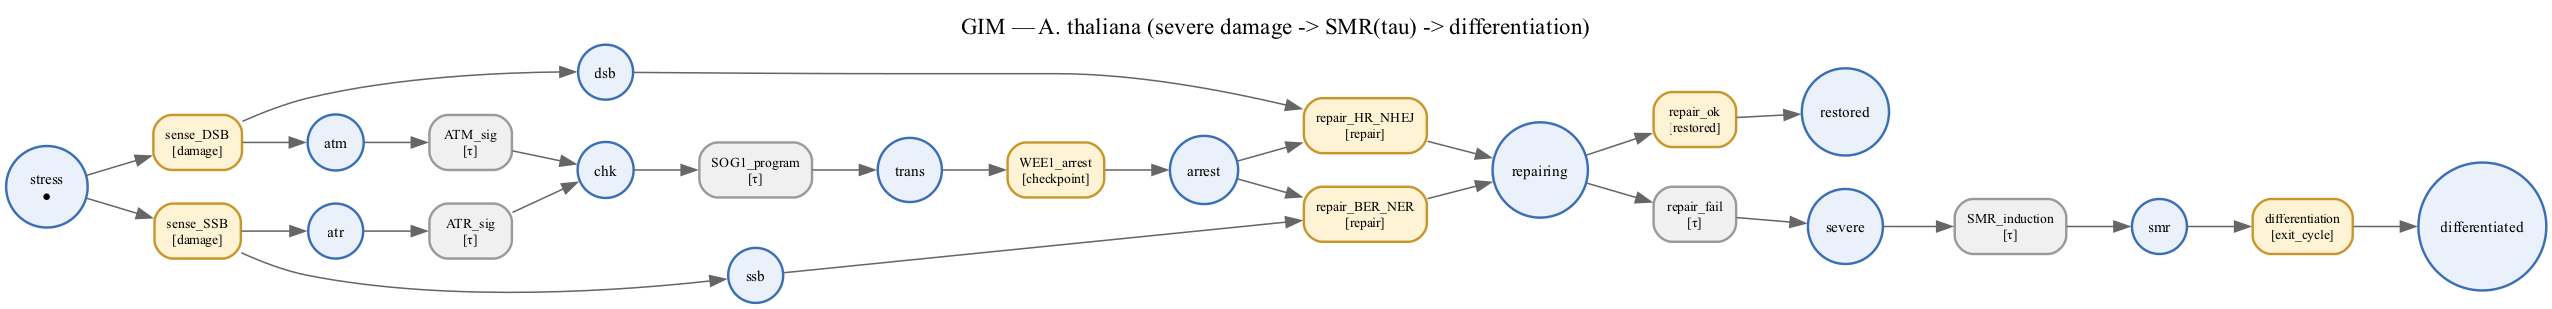

In [13]:
net_h = cbm.ddr_animal()
net_a = cbm.ddr_plant()
print("GIM animal:", len(net_h.places), "places,", len(net_h.transitions),
      "transitions, safe =", net_h.is_safe())
print("GIM plant :", len(net_a.places), "places,", len(net_a.transitions),
      "transitions, safe =", net_a.is_safe())
show_petri(net_h, "GIM — animal/human (severe damage -> apoptosis)")
show_petri(net_a, "GIM — A. thaliana (severe damage -> SMR(tau) -> differentiation)")

## Phase 5 — Partial behavioural comparison

We build the **reachability graph (LTS)** of each net and compare their observable
behaviour: strong bisimulation, **weak** bisimulation (abstracts `τ`), the
**simulation** preorders, and the **behavioural distance** (Jaccard of weak
observable traces).

animal LTS: 13 states, 13 edges
plant  LTS: 14 states, 14 edges


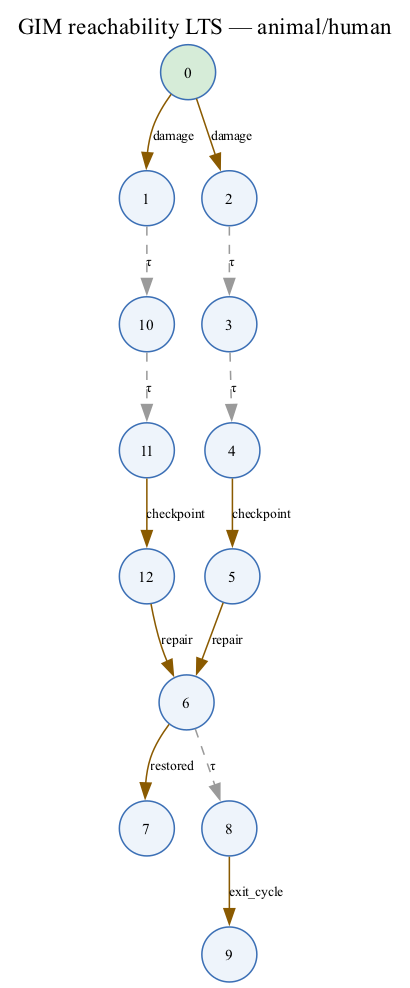

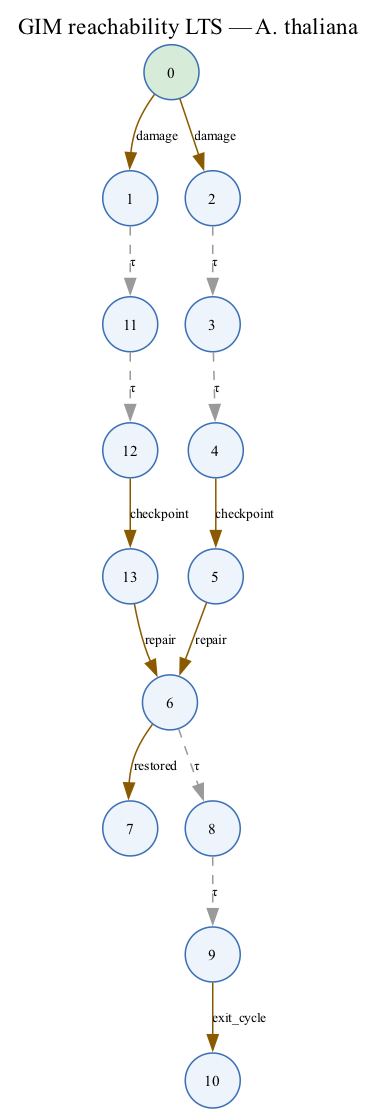

In [14]:
lts_h = net_h.reachability_lts()
lts_a = net_a.reachability_lts()
print(f"animal LTS: {len(lts_h.states)} states, {len(lts_h.edges)} edges")
print(f"plant  LTS: {len(lts_a.states)} states, {len(lts_a.edges)} edges")
show_lts(lts_h, "GIM reachability LTS — animal/human")
show_lts(lts_a, "GIM reachability LTS — A. thaliana")

In [15]:
print("== GIM module ==")
print("strong bisimulation :", cbm.strong_bisimilar(lts_h, lts_a))
print("weak bisimulation   :", cbm.weak_bisimilar(lts_h, lts_a))
print("plant  <= animal    :", cbm.weak_simulates(lts_a, lts_h))
print("animal <= plant     :", cbm.weak_simulates(lts_h, lts_a))
print("behavioural distance:", round(cbm.behavioural_distance(lts_h, lts_a), 3))
print()
print("-> NOT strongly bisimilar (internal SMR/tau events differ) but WEAKLY")
print("   bisimilar: the same observable behaviour through the interface.")

== GIM module ==
strong bisimulation : False
weak bisimulation   : True
plant  <= animal    : True
animal <= plant     : True
behavioural distance: 0.0

-> NOT strongly bisimilar (internal SMR/tau events differ) but WEAKLY
   bisimilar: the same observable behaviour through the interface.


### Sanity checks (including falsifiability)

A system is weakly bisimilar to itself; strong bisimilarity implies weak; and if
we **break the interface** (rename one observable) comparability **must**
disappear.

In [16]:
# 1) Reflexivity
assert cbm.weak_bisimilar(lts_h, lts_h)
assert cbm.behavioural_distance(lts_h, lts_h) == 0.0
# 2) Strong => weak (on the same system)
assert cbm.strong_bisimilar(lts_h, lts_h) and cbm.weak_bisimilar(lts_h, lts_h)
# 3) Falsifiability: rename the 'checkpoint' observable in the plant
broken = cbm.PetriNet(
    "GIM_plant_broken",
    [cbm.Transition(t.name, dict(t.pre), dict(t.post),
                    ("checkpoint_BROKEN" if t.label == "checkpoint" else t.label))
     for t in cbm.ddr_plant().transitions],
    dict(cbm.ddr_plant().init))
lts_broken = broken.reachability_lts()
assert not cbm.weak_bisimilar(lts_h, lts_broken)
print("OK: reflexivity, strong=>weak, and interface falsifiability all hold.")
print("Broken interface -> distance =",
      round(cbm.behavioural_distance(lts_h, lts_broken), 3),
      "| weak bisimilar =", cbm.weak_bisimilar(lts_h, lts_broken))

OK: reflexivity, strong=>weak, and interface falsifiability all hold.
Broken interface -> distance = 0.8 | weak bisimilar = False


## Phase 6 — Partial-comparability criterion (all modules)

Verdict rule: *weak bisimulation* ⇒ comparable; *simulation one way* ⇒ partial;
otherwise ⇒ not comparable.

In [17]:
res = cbm.run_full_analysis(k=6)
tab = pd.DataFrame([c.__dict__ for c in res])[
    ["module", "strong_bisimilar", "weak_bisimilar",
     "plant_simulated_by_animal", "animal_simulated_by_plant",
     "distance", "verdict"]]
tab.columns = ["Module", "Strong bisim.", "Weak bisim.",
               "Plant<=Animal", "Animal<=Plant", "Distance", "Verdict"]
display(tab)

,Module,Strong bisim.,Weak bisim.,Plant<=Animal,Animal<=Plant,Distance,Verdict
0,GIM,False,True,True,True,0.000000,Comparable (weak bisimulation)
1,DCE,False,True,True,True,0.000000,Comparable (weak bisimulation)
2,SPS,False,True,True,True,0.000000,Comparable (weak bisimulation)
3,RCD,False,False,True,False,0.142857,Partial: sub-mechanism simulated (plant ⊑ animal)
4,AID,False,False,False,False,0.428571,Not comparable


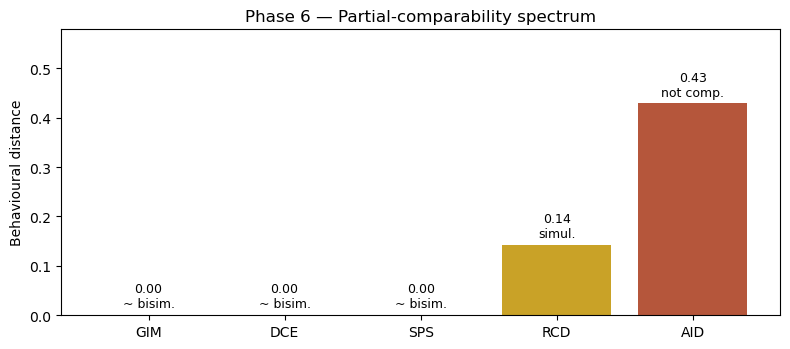

In [18]:
colors = []
for c in res:
    if c.weak_bisimilar: colors.append("#4a9b5e")
    elif c.plant_simulated_by_animal or c.animal_simulated_by_plant: colors.append("#c9a227")
    else: colors.append("#b5563b")
fig, ax = plt.subplots(figsize=(8, 3.6))
mods = [c.module for c in res]; dist = [c.distance for c in res]
ax.bar(mods, dist, color=colors)
for i, c in enumerate(res):
    tag = ("~ bisim." if c.weak_bisimilar else
           ("simul." if (c.plant_simulated_by_animal or c.animal_simulated_by_plant)
            else "not comp."))
    ax.text(i, c.distance + 0.01, f"{c.distance:.2f}\n{tag}", ha="center",
            va="bottom", fontsize=9)
ax.set_ylabel("Behavioural distance"); ax.set_ylim(0, max(dist) + 0.15)
ax.set_title("Phase 6 — Partial-comparability spectrum")
plt.tight_layout(); plt.show()

## Safeguard 1 — Verdict invariance under silent (τ) refinement

How finely we draw internal steps is a modelling choice with no biological
content. Because inserting a silent step preserves the weak‑bisimulation class
(`τ.P ≈ P`), refining a model must leave the verdict unchanged. We test this on
300 random refinements per module — a value below 100% would reveal a hidden
dependence on internal granularity (or an accidental reliance on strong
bisimulation).

In [19]:
rob = pd.DataFrame([cbm.robustness_under_tau_refinement(m, n=300, n_ins=4, seed=7)
                    for m in cbm.MODULES])
display(rob[["module", "base_verdict", "frac_bisim_preserved",
             "frac_verdict_preserved", "n"]])
print("All modules preserve the verdict under silent refinement:",
      bool((rob["frac_verdict_preserved"] == 1.0).all()))

,module,base_verdict,frac_bisim_preserved,frac_verdict_preserved,n
0,GIM,Comparable (weak bisimulation),1.0,1.0,300
1,DCE,Comparable (weak bisimulation),1.0,1.0,300
2,SPS,Comparable (weak bisimulation),1.0,1.0,300
3,RCD,Partial: sub-mechanism simulated (plant ⊑ animal),1.0,1.0,300
4,AID,Not comparable,1.0,1.0,300


All modules preserve the verdict under silent refinement: True


## Safeguard 2 — Label-permutation null test

Could the observed comparability arise by chance? We scramble the plant's
observable interface (relabel each observable edge with probability 0.6 to a
random label from the same alphabet), keeping the control-flow skeleton, and build
a null distribution of distances to the animal model over 2000 permutations. A
conserved module should sit in the extreme low tail; the immune control should
not. Because this is a five-module family of tests, we report both empirical
p-values and Benjamini–Hochberg FDR-corrected q-values.


,module,observed_distance,null_mean,null_sd,p_value,q_value_bh
0,GIM,0.000000,0.767636,0.177401,0.005997,0.029985
1,DCE,0.000000,0.773578,0.223271,0.021989,0.036648
2,SPS,0.000000,0.820020,0.165595,0.013493,0.033733
3,RCD,0.142857,0.789123,0.192527,0.031984,0.039980
4,AID,0.428571,0.750438,0.174316,0.153923,0.153923


OK: conserved modules survive BH-FDR correction; AID remains non-significant.


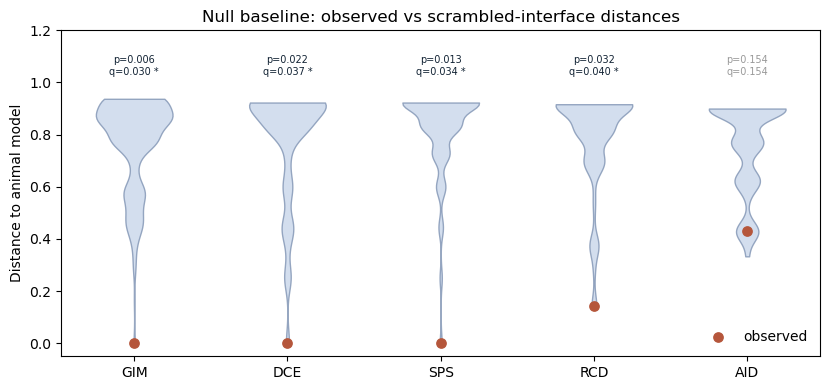

In [20]:
nb = cbm.null_baseline_suite(cbm.MODULES, n=2000, frac=0.6, seed=7)
nb_tab = pd.DataFrame([{k: v for k, v in r.items() if k != "null"} for r in nb])
display(nb_tab)

conserved = nb_tab[nb_tab["module"] != "AID"]
control_q = float(nb_tab.loc[nb_tab["module"] == "AID", "q_value_bh"].iloc[0])
assert (conserved["q_value_bh"] < 0.05).all()
assert control_q >= 0.05
print("OK: conserved modules survive BH-FDR correction; AID remains non-significant.")

fig, ax = plt.subplots(figsize=(8.4, 4))
parts = ax.violinplot([r["null"] for r in nb], showextrema=False)
for pc in parts["bodies"]:
    pc.set_facecolor("#c9d6ea"); pc.set_edgecolor("#7f93b3"); pc.set_alpha(0.8)
xs = np.arange(1, len(nb) + 1)
ax.scatter(xs, [r["observed_distance"] for r in nb], color="#b5563b", s=45,
           zorder=5, label="observed")
for i, r in enumerate(nb):
    star = " *" if r["q_value_bh"] < 0.05 else ""
    ax.text(xs[i], 1.03, f"p={r['p_value']:.3f}\nq={r['q_value_bh']:.3f}{star}",
            ha="center", fontsize=7,
            color=("#123" if r["q_value_bh"] < 0.05 else "#999"))
ax.set_xticks(xs); ax.set_xticklabels(list(cbm.MODULES)); ax.set_ylim(-0.05, 1.2)
ax.set_ylabel("Distance to animal model")
ax.set_title("Null baseline: observed vs scrambled-interface distances")
ax.legend(frameon=False, loc="lower right"); plt.tight_layout(); plt.show()


## Safeguard 2b — Targeted interface-necessity test

A hostile reviewer could argue that the global label permutation is too blunt. We
therefore rename each observable label on the plant side, one at a time, while
leaving the control-flow skeleton untouched. In the weakly bisimilar modules,
every shared label should be consequential: renaming it should break weak
bisimilarity and increase distance.


In [21]:
iface_rows = []
for m in cbm.MODULES:
    iface_rows.extend(cbm.interface_necessity(m, k=6))
iface = pd.DataFrame(iface_rows)
display(iface[["module", "label", "base_distance", "perturbed_distance",
               "delta_distance", "verdict_changed", "weak_bisimilar_after"]])

weak_modules = {c.module for c in res if c.weak_bisimilar}
weak_iface = iface[iface["module"].isin(weak_modules)]
assert (weak_iface["delta_distance"] > 0).all()
assert (~weak_iface["weak_bisimilar_after"]).all()
print("OK: every observable label in weakly bisimilar modules is consequential.")

summary_iface = (iface.groupby("module")
                 .agg(min_delta=("delta_distance", "min"),
                      max_delta=("delta_distance", "max"),
                      changed=("verdict_changed", "sum"),
                      labels=("label", "count"))
                 .reset_index())
display(summary_iface)


,module,label,base_distance,perturbed_distance,delta_distance,verdict_changed,weak_bisimilar_after
0,GIM,checkpoint,0.000000,0.800000,0.800000,True,False
1,GIM,damage,0.000000,0.909091,0.909091,True,False
2,GIM,exit_cycle,0.000000,0.285714,0.285714,True,False
3,GIM,repair,0.000000,0.666667,0.666667,True,False
4,GIM,restored,0.000000,0.285714,0.285714,True,False
5,DCE,atp,0.000000,0.444444,0.444444,True,False
6,DCE,branch_resp,0.000000,0.444444,0.444444,True,False
7,DCE,glycolysis,0.000000,0.833333,0.833333,True,False
8,DCE,reprogram,0.000000,0.444444,0.444444,True,False
9,DCE,uptake,0.000000,0.923077,0.923077,True,False


OK: every observable label in weakly bisimilar modules is consequential.


,module,min_delta,max_delta,changed,labels
0,AID,0.000000,0.471429,0,4
1,DCE,0.444444,0.923077,5,5
2,GIM,0.285714,0.909091,5,5
3,RCD,0.232143,0.773810,5,5
4,SPS,0.250000,0.923077,6,6


## Safeguard 2c — Seed sensitivity of the null baseline

The default null test uses fixed seeds for reproducibility. Here we repeat the
full 2000-permutation suite over five seeds and recompute BH-FDR each time. This
keeps the main equivalence claims honest: `GIM`, `DCE`, and `SPS` should remain
below 0.05; `RCD` may be borderline and is therefore reported as partial rather
than as full equivalence.


In [22]:
seed_sens = pd.DataFrame(cbm.null_seed_sensitivity(cbm.MODULES, n=2000, frac=0.6))
display(seed_sens)

stable = seed_sens[seed_sens["module"].isin(["GIM", "DCE", "SPS"])]
assert stable["all_q_lt_0_05"].all()
assert not bool(seed_sens.loc[seed_sens["module"] == "AID", "all_q_lt_0_05"].iloc[0])
print("OK: GIM/DCE/SPS are stable across seeds; AID remains non-significant.")
print("RCD q range:", seed_sens.loc[seed_sens["module"] == "RCD", ["q_min", "q_max"]].to_dict("records")[0])


,module,seeds,n_per_seed,q_min,q_median,q_max,p_min,p_median,p_max,all_q_lt_0_05
0,GIM,"1,7,13,29,101",2000,0.017491,0.029985,0.032484,0.003498,0.005997,0.007496,True
1,DCE,"1,7,13,29,101",2000,0.031651,0.034150,0.036648,0.014993,0.020490,0.021989,True
2,SPS,"1,7,13,29,101",2000,0.031651,0.033733,0.034983,0.012994,0.013993,0.019490,True
3,RCD,"1,7,13,29,101",2000,0.039980,0.048726,0.054973,0.031984,0.038981,0.043978,False
4,AID,"1,7,13,29,101",2000,0.153923,0.160420,0.166417,0.153923,0.160420,0.166417,False


OK: GIM/DCE/SPS are stable across seeds; AID remains non-significant.
RCD q range: {'q_min': 0.039980009995002494, 'q_max': 0.054972513743128434}


## Safeguard 3 — Stability of the distance in $k$

The distance uses traces truncated at depth $k$. For acyclic modules the
observable language is finite, so $d_k$ is exact once $k$ reaches the module
diameter. The curves should plateau — confirming $k=6$ is not a free
parameter.

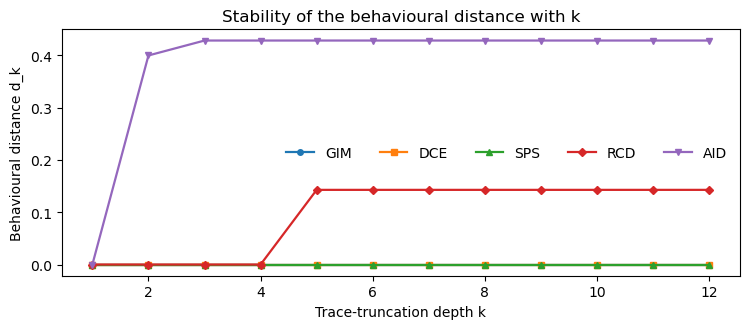

In [23]:
fig, ax = plt.subplots(figsize=(7.6, 3.4))
markers = {"GIM": "o", "DCE": "s", "SPS": "^", "RCD": "D", "AID": "v"}
for m in cbm.MODULES:
    curve = cbm.distance_curve(m, kmax=12)
    ax.plot([k for k, _ in curve], [d for _, d in curve],
            marker=markers[m], label=m, linewidth=1.6, markersize=4)
ax.set_xlabel("Trace-truncation depth k"); ax.set_ylabel("Behavioural distance d_k")
ax.set_title("Stability of the behavioural distance with k")
ax.legend(frameon=False, ncol=5); plt.tight_layout(); plt.show()

## What-if exploration: what exactly breaks RCD comparability?

Hypothesis: the only thing preventing weak bisimilarity of RCD is the absence of a
canonical caspase-apoptosis observable in the plant. We test it by *patching* the
metacaspase execution to emit the `apoptosis` observable.

In [24]:
patched = cbm.PetriNet(
    "RCD_plant_patched",
    [cbm.Transition(t.name, dict(t.pre), dict(t.post),
                    ("apoptosis" if t.name == "metacaspase_exec" else t.label))
     for t in cbm.death_plant().transitions],
    dict(cbm.death_plant().init))
lts_rcd_h = cbm.death_animal().reachability_lts()
print("RCD original  — weak bisimilar:",
      cbm.weak_bisimilar(lts_rcd_h, cbm.death_plant().reachability_lts()))
print("RCD patched   — weak bisimilar:",
      cbm.weak_bisimilar(lts_rcd_h, patched.reachability_lts()))
print("\n-> Confirms the single factor breaking RCD comparability is the")
print("   canonical apoptotic-execution observable, absent in the plant.")

RCD original  — weak bisimilar: False
RCD patched   — weak bisimilar: True

-> Confirms the single factor breaking RCD comparability is the
   canonical apoptotic-execution observable, absent in the plant.


## Generalisation across model organisms

The formal comparison API does not depend on plants, animals or cancer — it compares any two
module models over a shared interface. To show this, we apply the **same**
routine to one deeply conserved module (the **cell cycle**) between a human
reference and a panel of classical model organisms: **mouse**, **budding yeast**
and **Arabidopsis**. We also include a **scrambled same-alphabet control**: it
uses the same observable labels but in a biologically incoherent order. Mouse
shares the mammalian human structure; yeast and plant keep the conserved core
(START/G1–S, ORC/MCM licensing, S phase, cyclin/CDK G2–M, division) but route it
through organism-specific internal regulators modelled as `τ` steps. The control
should be rejected; otherwise the method would be matching vocabulary rather than
behaviour.


,organism,strong_bisimilar,weak_bisimilar,distance,verdict
0,Mouse,True,True,0.000000,Comparable (strong: near-identical core)
1,Yeast,False,True,0.000000,Comparable (weak bisimulation)
2,Arabidopsis,False,True,0.000000,Comparable (weak bisimulation)
3,Scrambled-control,False,False,0.923077,Not comparable


OK: the scrambled same-alphabet control is rejected.


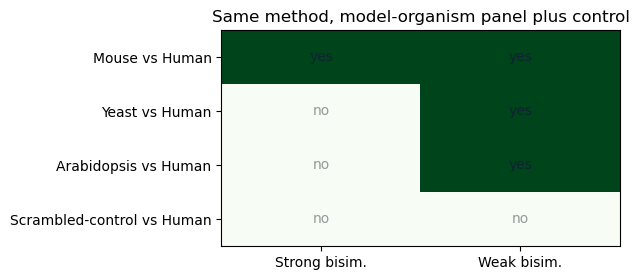

Mouse is strongly bisimilar (near-identical mammalian circuit); yeast and
Arabidopsis are weakly bisimilar (comparable through the interface despite
organism-specific internal wiring). The scrambled same-alphabet control is
not comparable, so shared labels alone are not enough. This is a
portability demonstration for one module, not a whole-organism claim.


In [25]:
gen = pd.DataFrame(cbm.generalization_analysis(k=6))
display(gen[["organism", "strong_bisimilar", "weak_bisimilar", "distance", "verdict"]])

control = gen.loc[gen["organism"] == "Scrambled-control"].iloc[0]
assert not bool(control["weak_bisimilar"])
assert control["distance"] > 0.5
print("OK: the scrambled same-alphabet control is rejected.")

M = np.array([[int(r.strong_bisimilar), int(r.weak_bisimilar)]
              for r in gen.itertuples()])
fig, ax = plt.subplots(figsize=(6.4, 2.9))
ax.imshow(M, cmap="Greens", vmin=0, vmax=1, aspect="auto")
ax.set_xticks([0, 1]); ax.set_xticklabels(["Strong bisim.", "Weak bisim."])
ax.set_yticks(range(len(gen)))
ax.set_yticklabels([f"{o} vs Human" for o in gen["organism"]])
for i in range(M.shape[0]):
    for j in range(M.shape[1]):
        ax.text(j, i, "yes" if M[i, j] else "no", ha="center", va="center",
                color="#123" if M[i, j] else "#999")
ax.set_title("Same method, model-organism panel plus control")
plt.tight_layout(); plt.show()

print("Mouse is strongly bisimilar (near-identical mammalian circuit); yeast and")
print("Arabidopsis are weakly bisimilar (comparable through the interface despite")
print("organism-specific internal wiring). The scrambled same-alphabet control is")
print("not comparable, so shared labels alone are not enough. This is a")
print("portability demonstration for one module, not a whole-organism claim.")


## Summary

- The independent synthetic suite recovers all six predeclared formal relations.
- The Python engine and mCRL2 202607.0 agree on all strong and weak decisions in
  the synthetic and public-model controls. Exact mCRL2 weak-trace outcomes also
  match every predeclared trace control.
- The independent weak-simulation game agrees on all 67,600 ordered pairs among
  the 260 LTSs with at most two states and labels in `{a, tau}`.
- The public mammalian cell-cycle and p53--Mdm2 models generate nontrivial
  asynchronous systems of 826 and 17 reachable states, respectively. Their
  controls verify the software path on external dynamics, not biological truth.
- Structure-only medoids from 72 BT20, 191 BT549 and 21 MCF7 public Boolean
  networks generate nine genuinely cross-model comparisons under shared held-out
  perturbations. Python and mCRL2 agree on all decisions: six pairs have one-way
  simulation and three are not comparable.
- CASPOTS held-out compatibility is reproduced deterministically, but native
  medoids rank first or tie in only two of three cell lines. Native specificity
  remains unsupported (p=0.25). Formal relation classes are summarized
  nominally with direction preserved; no ordinal class test is used.
- Weak bisimulation gives the correct binary equivalence decision in every case;
  trace equality scores 5/6, LTS-GDA 4/6, the structural profile 3/6 and direct
  PN-GDDA 2/6. PN-GDDA calls all six pairs equivalent at the diagnostic 0.9
  threshold and cannot exceed 4/6 over any score cutoff.
- The generated 151-topology/592-slot catalog matches both inspected Holmes
  releases, and an independent four-node score matches Holmes 1.1.1 to 12
  decimal places. The 576-orbit automorphism sensitivity changes no decision.
- Synchronous-update stress preserves seven of nine HPN formal classes; two
  one-way simulations become non-comparability. LTS-GDA distance has
  `rho=0.669` with held-out profile distance, but its exact `p=0.097` remains
  inconclusive.
- Runtime and candidate-relation size are reported explicitly; timings are
  machine-dependent, while all categorical outputs and model sizes are
  deterministic.
- The unchanged GIM Petri-net structures score 0.9976 by PN-GDDA under all
  interfaces. Interfaces A (coarse) and B (pathway-level) are weakly bisimilar
  with d6=0, whereas interface C (terminal mechanism resolved) is not
  comparable with d6=0.352941.
- These model-level results do not establish experimental equivalence between
  Arabidopsis and human biology. They identify conditional hypotheses and
  demonstrate how the software classifies explicit network models.

Regenerate the complete artifact from the project root with
`make external-validation && make figures && make test && make notebook`.
